In [11]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [4]:
import requests
import io
import pandas as pd
# URL of the CSV file
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"
# Fetch the data from the URL
response = requests.get(URL)
# Raise an error if the request failed
response.raise_for_status()
# Convert the response content into a readable format for pandas
csv_content = io.StringIO(response.text)
# Read the CSV data into a pandas dataframe
df = pd.read_csv(csv_content)
# Print confirmation
print('Data downloaded and read into a dataframe!')
# Optional: Show the first few rows of the dataframe
print(df.head())

Data downloaded and read into a dataframe!
         Date  Year Month  Recession  Consumer_Confidence  Seasonality_Weight  \
0  1980-01-31  1980   Jan          1               108.24                0.45   
1  1980-01-31  1980   Jan          1               108.24                0.45   
2  1980-01-31  1980   Jan          1               108.24                0.36   
3  1980-01-31  1980   Jan          1               108.24                0.38   
4  1980-02-29  1980   Feb          1                98.75                0.46   

   Price  Advertising_Expenditure  Competition    GDP  Growth_Rate  \
0  27704                   1417.5            7  60.22         0.01   
1  77270                    763.7            7  60.22         0.01   
2  19665                   1417.5            7  60.22         0.01   
3  36986                   1417.5            7  60.22         0.01   
4  26609                   2773.4            4  45.99        -0.31   

   unemployment_rate  Automobile_Sales     Vehicl

In [5]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [6]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

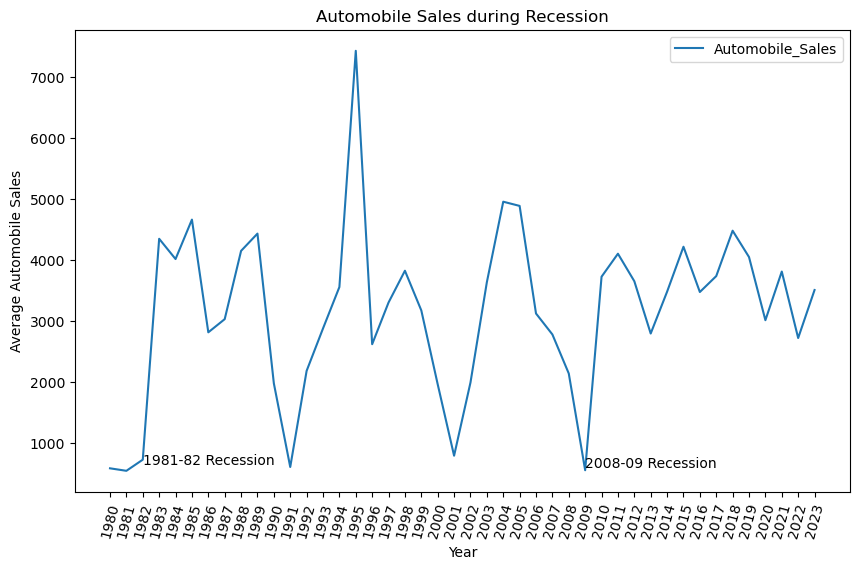

In [9]:
# Create the data for plotting
df_line = df.groupby('Year')['Automobile_Sales'].mean()
# Create figure
plt.figure(figsize=(10,6))
# Plot line chart
df_line.plot(kind='line')
# Show every year on x-axis
plt.xticks(list(range(1980, 2024)), rotation=75)
# Labels and title
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Automobile Sales during Recession')
# Annotations for recession years
plt.text(1982, 650, '1981-82 Recession')
plt.text(2009, 600, '2008-09 Recession')
plt.legend()
plt.show()

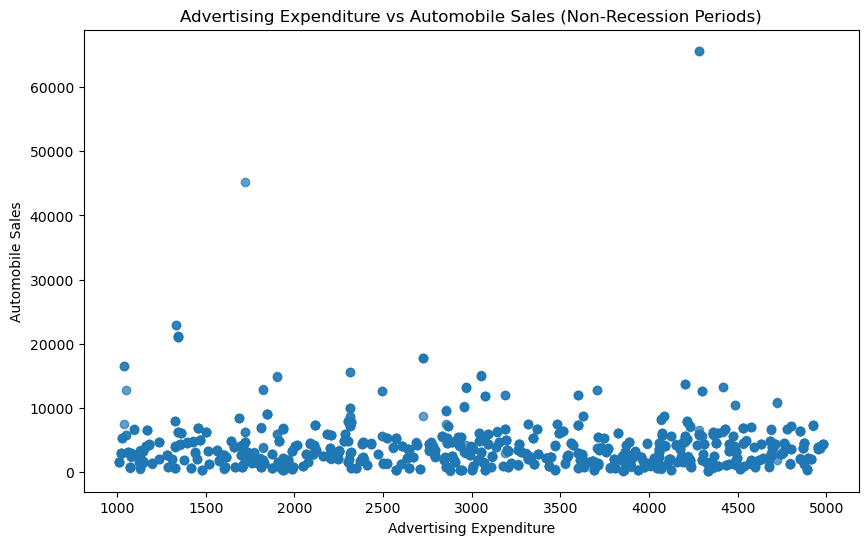

In [10]:
# Filter data for non-recession periods
df_non_recession = df[df['Recession'] == 0]
# Create figure
plt.figure(figsize=(10, 6))
# Scatter plot
plt.scatter(df_non_recession['Advertising_Expenditure'],
            df_non_recession['Automobile_Sales'],
            alpha=0.7)
# Labels and title
plt.xlabel('Advertising Expenditure')
plt.ylabel('Automobile Sales')
plt.title('Advertising Expenditure vs Automobile Sales (Non-Recession Periods)')
plt.show()

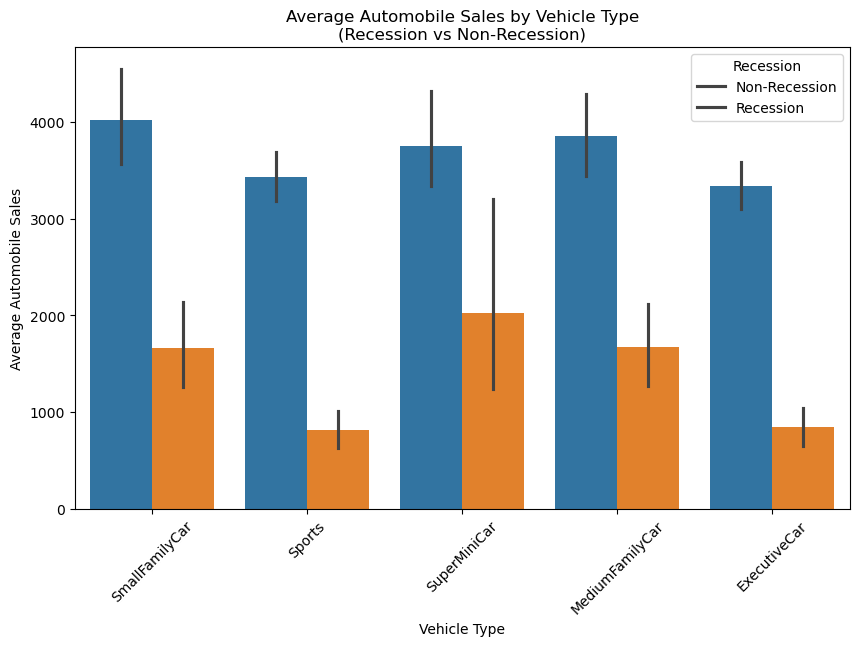

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create the comparison plot
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x='Vehicle_Type',
    y='Automobile_Sales',
    hue='Recession',
    estimator='mean'
)
plt.title('Average Automobile Sales by Vehicle Type\n(Recession vs Non-Recession)')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Automobile Sales')
plt.legend(title='Recession', labels=['Non-Recession', 'Recession'])
plt.xticks(rotation=45)
plt.show()

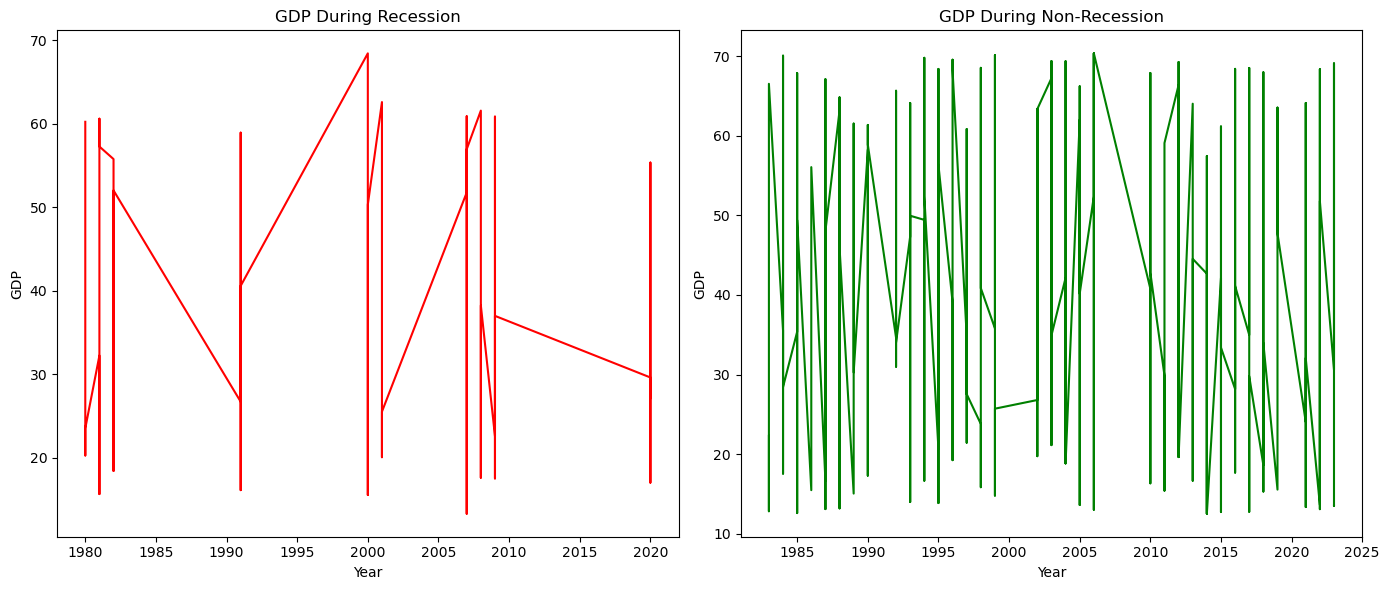

In [13]:
import matplotlib.pyplot as plt
# Create data for recession and non-recession periods
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]
# Create figure and subplots
fig = plt.figure(figsize=(14, 6))
# Recession GDP trend
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(rec_data['Year'], rec_data['GDP'], color='red')
ax1.set_title('GDP During Recession')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')
# Non-Recession GDP trend
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(non_rec_data['Year'], non_rec_data['GDP'], color='green')
ax2.set_title('GDP During Non-Recession')
ax2.set_xlabel('Year')
ax2.set_ylabel('GDP')
plt.tight_layout()
plt.show()

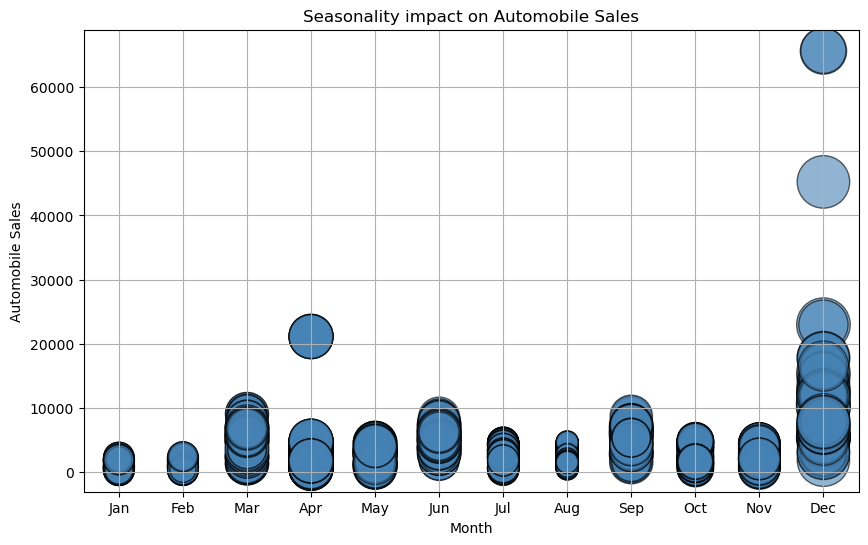

In [14]:
import matplotlib.pyplot as plt
# Filter data for non-recession period
non_rec_data = df[df['Recession'] == 0]
# Create bubble plot
plt.figure(figsize=(10,6))
plt.scatter(
    non_rec_data['Month'],
    non_rec_data['Automobile_Sales'],
    s=non_rec_data['Seasonality_Weight'] * 1000,  # Bubble size
    alpha=0.6,
    color='steelblue',
    edgecolors='black'
)
plt.title('Seasonality impact on Automobile Sales')
plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.grid(True)
plt.show()

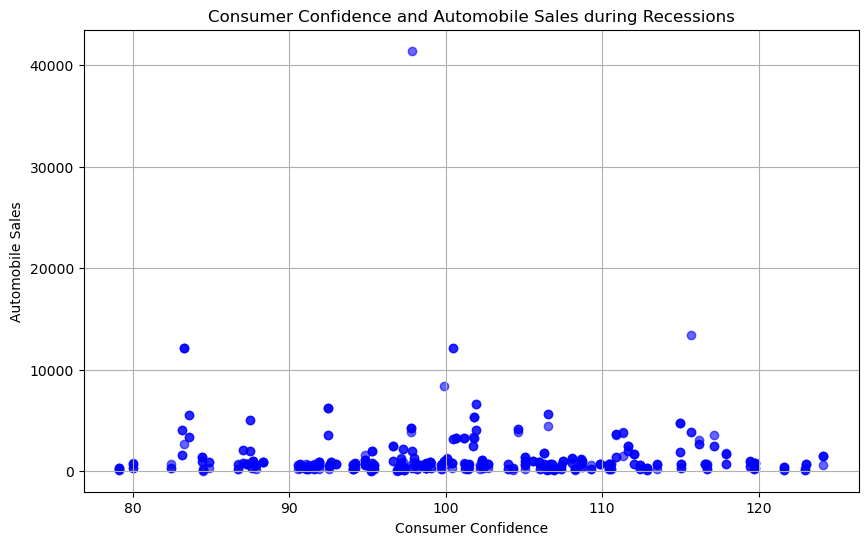

In [15]:
import matplotlib.pyplot as plt
# Filter data for recession period
rec_data = df[df['Recession'] == 1]
# Create scatter plot
plt.figure(figsize=(10,6))
plt.scatter(
    rec_data['Consumer_Confidence'],
    rec_data['Automobile_Sales'],
    color='blue',
    alpha=0.6
)
plt.title('Consumer Confidence and Automobile Sales during Recessions')
plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile Sales')
plt.grid(True)
plt.show()

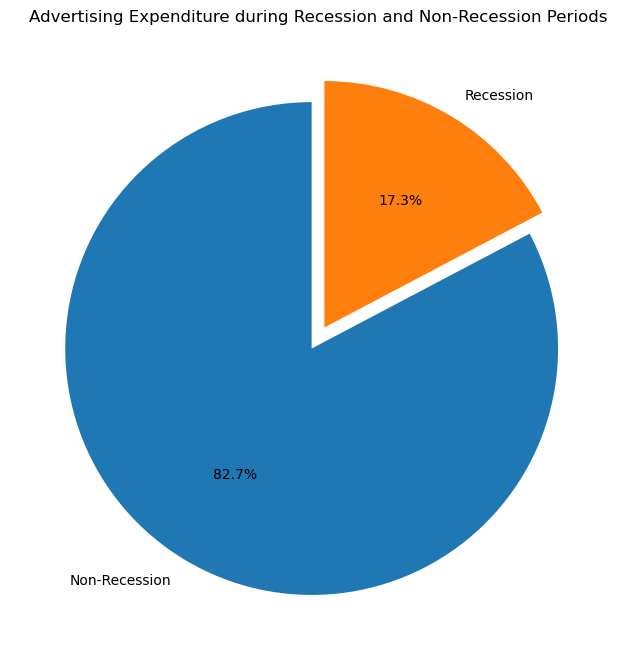

In [16]:
import matplotlib.pyplot as plt
# Sum advertising expenditure for recession and non-recession periods
ad_data = df.groupby('Recession')['Advertising_Expenditure'].sum()
# Create pie chart
plt.figure(figsize=(8,8))
plt.pie(
    ad_data,
    labels=['Non-Recession', 'Recession'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0.05)
)
plt.title('Advertising Expenditure during Recession and Non-Recession Periods')
plt.show()

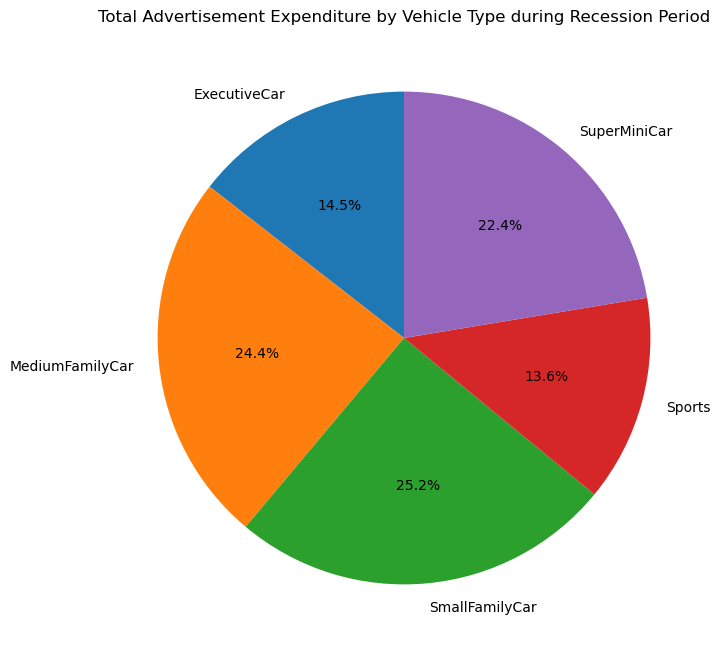

In [17]:
import matplotlib.pyplot as plt
# Filter data for recession period
rec_data = df[df['Recession'] == 1]
# Group by Vehicle Type and sum Advertisement Expenditure
ad_exp = rec_data.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()
# Create pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    ad_exp,
    labels=ad_exp.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Total Advertisement Expenditure by Vehicle Type during Recession Period')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for recession period
rec_data = df[df['Recession'] == 1]

# Create the line plot
plt.figure(figsize=(10,6))

sns.lineplot(
    data=rec_data,
    x='unemployment_rate',
    y='Automobile_Sales',
    hue='Vehicle_Type',
    marker='o'
)

plt.title('Effect of Unemployment Rate on Vehicle Type and Sales')
plt.xlabel('Unemployment Rate')
plt.ylabel('Automobile Sales')
plt.legend(title='Vehicle Type')

plt.show()